In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

In [4]:
df = pd.read_csv("customer_churn.csv")
print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (1200, 13)


,CustomerID,TenureMonths,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,SupportTickets,TechSupportCalls,SeniorCitizen,Dependents,PaperlessBilling,Churn
0,CUST10000,7,75.14,628.18,One year,No,Bank transfer,1,2,No,No,Yes,1
1,CUST10001,56,104.95,5871.13,One year,Fiber optic,Electronic check,0,2,No,No,Yes,1
2,CUST10002,48,119.85,5828.92,Month-to-month,DSL,Electronic check,3,2,Yes,Yes,No,1
3,CUST10003,32,100.67,3155.19,One year,Fiber optic,Credit card,3,3,No,Yes,No,1
4,CUST10004,32,126.14,4061.03,One year,DSL,Credit card,4,0,No,No,Yes,1


In [5]:
print("\nMissing values:")
print(df.isnull().sum())

print("\nChurn distribution:")
print(df["Churn"].value_counts())


Missing values:
CustomerID           0
TenureMonths         0
MonthlyCharges       0
TotalCharges        24
Contract             0
InternetService      0
PaymentMethod       12
SupportTickets       0
TechSupportCalls     0
SeniorCitizen        0
Dependents           0
PaperlessBilling     0
Churn                0
dtype: int64

Churn distribution:
Churn
1    1030
0     170
Name: count, dtype: int64


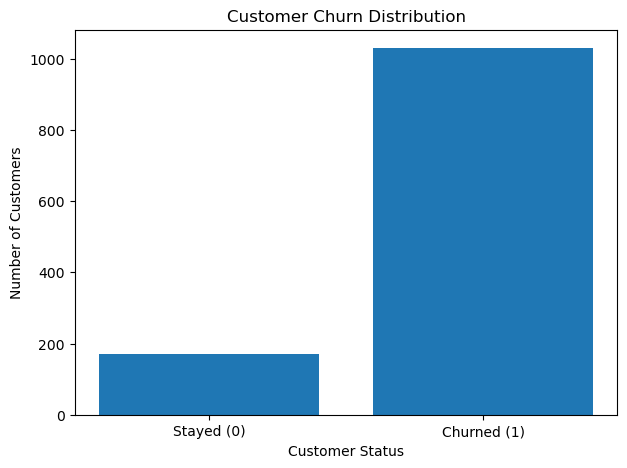

In [6]:
counts = df["Churn"].value_counts().sort_index()
plt.figure(figsize=(7, 5))
plt.bar(["Stayed (0)", "Churned (1)"], counts.values)
plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.show()

In [7]:
X = df.drop(columns=["CustomerID", "Churn"])
y = df["Churn"]

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()


In [8]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=250, max_depth=10, random_state=42, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []
trained_models = {}

for name, classifier in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    pipeline.fit(X_train, y_train)
    y_pred_model = pipeline.predict(X_test)
    y_prob_model = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred_model),
        "Precision": precision_score(y_test, y_pred_model, zero_division=0),
        "Recall": recall_score(y_test, y_pred_model, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_model, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob_model)
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
display(results_df)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.700000,0.958904,0.679612,0.795455,0.791690
3,Gradient Boosting,0.854167,0.883408,0.956311,0.918415,0.765563
2,Random Forest,0.858333,0.880531,0.966019,0.921296,0.763564
1,Decision Tree,0.700000,0.898810,0.733010,0.807487,0.612150


              precision    recall  f1-score   support

    No Churn       0.50      0.21      0.29        34
       Churn       0.88      0.97      0.92       206

    accuracy                           0.86       240
   macro avg       0.69      0.59      0.61       240
weighted avg       0.83      0.86      0.83       240

Accuracy: 0.8583
Precision: 0.8805
Recall: 0.9660
F1 Score: 0.9213
ROC-AUC: 0.7636


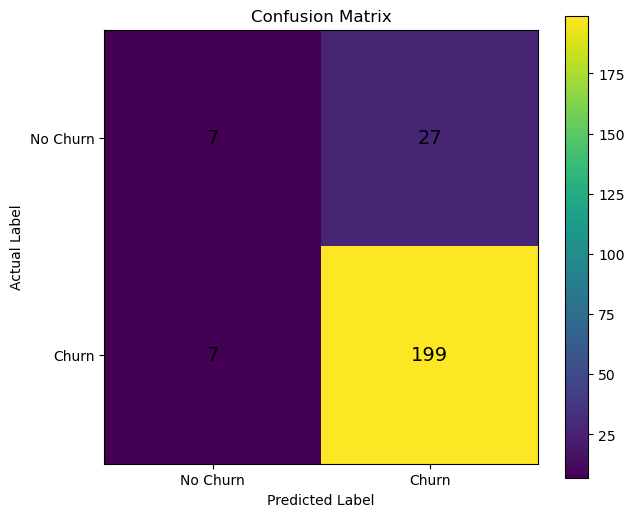

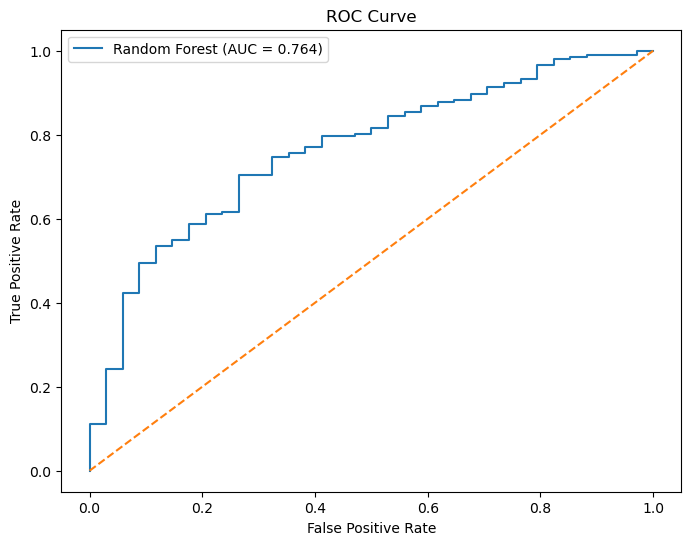

,Feature,Importance
0,numeric__TenureMonths,0.232042
2,numeric__TotalCharges,0.187310
1,numeric__MonthlyCharges,0.180231
4,numeric__TechSupportCalls,0.061188
3,numeric__SupportTickets,0.058016
7,categorical__Contract_Two year,0.026156
5,categorical__Contract_Month-to-month,0.025861
11,categorical__PaymentMethod_Bank transfer,0.021182
9,categorical__InternetService_Fiber optic,0.020083
8,categorical__InternetService_DSL,0.018807


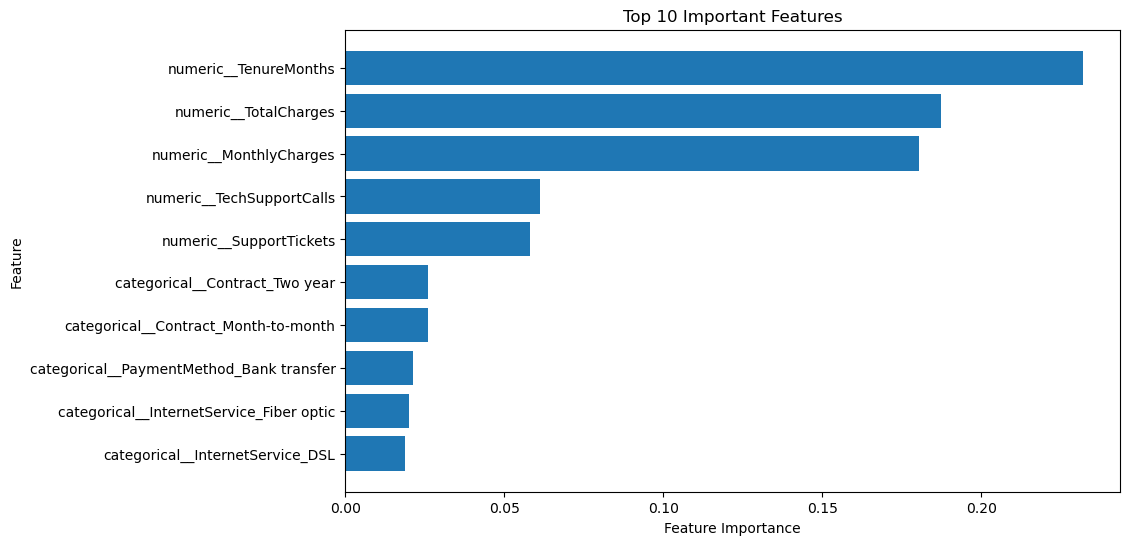

{'Churn Probability': '99.73%', 'Prediction': 'LIKELY TO CHURN', 'Risk Level': 'HIGH'}


In [11]:
final_model = trained_models["Random Forest"]

# 9. Final evaluation
y_pred = final_model.predict(X_test)
y_probability = final_model.predict_proba(X_test)[:, 1]

print(classification_report(
    y_test, y_pred,
    target_names=["No Churn", "Churn"],
    zero_division=0
))

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_probability)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# 10. Confusion matrix - Matplotlib only
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14)

plt.colorbar()
plt.show()

# 11. ROC curve
fpr, tpr, _ = roc_curve(y_test, y_probability)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 12. Feature importance
rf_model = final_model.named_steps["classifier"]
preprocessing_step = final_model.named_steps["preprocessor"]
feature_names = preprocessing_step.get_feature_names_out()

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance_df.head(15))

top_features = feature_importance_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.title("Top 10 Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

# 13. Individual customer prediction
def predict_customer_churn(customer_data):
    customer_df = pd.DataFrame([customer_data])
    probability = final_model.predict_proba(customer_df)[0, 1]

    if probability < 0.30:
        risk_level = "LOW"
    elif probability < 0.70:
        risk_level = "MEDIUM"
    else:
        risk_level = "HIGH"

    prediction = "LIKELY TO CHURN" if probability >= 0.50 else "LIKELY TO STAY"

    return {
        "Churn Probability": f"{probability * 100:.2f}%",
        "Prediction": prediction,
        "Risk Level": risk_level
    }

sample_customer = {
    "TenureMonths": 8,
    "MonthlyCharges": 95,
    "TotalCharges": 760,
    "Contract": "Month-to-month",
    "InternetService": "Fiber optic",
    "PaymentMethod": "Electronic check",
    "SupportTickets": 4,
    "TechSupportCalls": 3,
    "SeniorCitizen": "No",
    "Dependents": "No",
    "PaperlessBilling": "Yes"
}

print(predict_customer_churn(sample_customer))

In [12]:
joblib.dump(final_model, "churn_model.pkl")
print("Model saved as churn_model.pkl")

Model saved as churn_model.pkl
